# SVD-Based Collaborative Filtering

Two matrix factorization approaches for implicit-feedback music recommendation:

- **Truncated SVD** (scikit-learn) — factorize the full user-item matrix; grid-search the number of latent components `k`
- **FunkSVD** (SGD) — optimize latent factors on *observed* interactions only; grid-search `k`, learning rate, and regularization

Both models are evaluated with **Hit Rate @ K** on a held-out set of 14,936 test users.

In [1]:
import numpy as np
import json
from scipy.sparse import csr_matrix, coo_matrix
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

item_map          = json.load(open('data/item_map.json', 'r'))
test_ground_truth = json.load(open('data/test_ground_truth.json', 'r'))
train_matrix      = np.load('data/train_matrix.npz')
user_map          = json.load(open('data/user_map.json', 'r'))

## Data Loading

Reconstruct the sparse user-item matrix from the stored CSR components.

In [2]:
# Reconstruct CSR matrix from stored sparse components
R = csr_matrix(
    (train_matrix['data'], train_matrix['indices'], train_matrix['indptr']),
    shape=train_matrix['shape']
)

print(f"User-item matrix: {R.shape[0]:,} users Ã— {R.shape[1]:,} items")
print(f"Non-zero interactions: {R.nnz:,} ({R.nnz / (R.shape[0] * R.shape[1]) * 100:.2f}% density)")

User-item matrix: 26,014 users Ã— 7,238 items
Non-zero interactions: 1,347,225 (0.72% density)


## SVD Decomposition

Factorize **R** using Truncated SVD. `k` controls the number of latent factors â€” larger `k` captures more variance but risks overfitting.

Latent factors: 100
Cumulative explained variance: 0.301


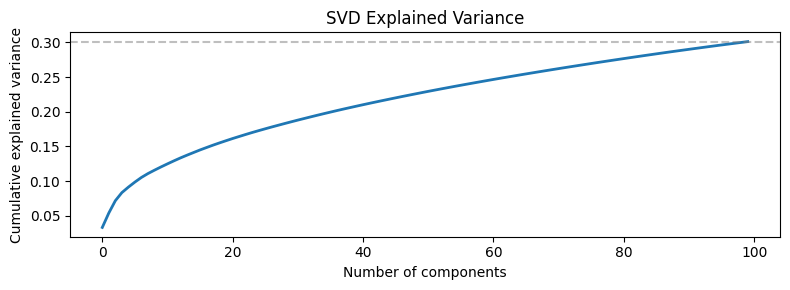

In [3]:
k = 100  # latent factors; balances expressiveness and generalization

svd = TruncatedSVD(n_components=k, random_state=42)
U_scaled = svd.fit_transform(R)   # shape (n_users, k) â€” already scaled by singular values
Vt = svd.components_              # shape (k, n_items)

print(f"Latent factors: {k}")
print(f"Cumulative explained variance: {svd.explained_variance_ratio_.sum():.3f}")

# Plot explained variance per component to see how quickly information concentrates
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.cumsum(svd.explained_variance_ratio_), linewidth=2)
ax.axhline(svd.explained_variance_ratio_.sum(), color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('SVD Explained Variance')
plt.tight_layout()
plt.show()

## Evaluation

For each test user, score all items using the reconstructed matrix and check if the held-out ground truth item appears in the top-K recommendations.

**Hit Rate @ K** = fraction of test users whose held-out item ranks in the top K predicted items.

In [4]:
# Filter to test users that appear in the training set
valid = [(user_map[uid], test_ground_truth[uid])
         for uid in test_ground_truth if uid in user_map]
test_user_indices, true_item_indices = zip(*valid)
test_user_indices = list(test_user_indices)
true_item_indices = list(true_item_indices)

# Compute predicted scores for all test users at once: (n_test, n_items)
scores = U_scaled[test_user_indices] @ Vt

# Mask items already interacted with â€” prevents recommending known items and wastes top-K slots
seen_mask = R[test_user_indices].toarray().astype(bool)
scores[seen_mask] = -np.inf

print(f"Evaluating {len(test_user_indices):,} test users against {R.shape[1]:,} items")

Evaluating 14,936 test users against 7,238 items


In [5]:
def hit_rate_at_k(scores, true_items, k):
    # argpartition finds top-k without full sort â€” much faster for large item sets
    top_k = np.argpartition(scores, -k, axis=1)[:, -k:]
    # broadcast true_items (n_test, 1) against top_k (n_test, k) â€” no Python loop
    hits = np.any(top_k == true_items[:, None], axis=1).sum()
    return hits / len(true_items)

true_item_indices = np.array(true_item_indices)

results = {}
for k_val in [10, 20, 50, 100]:
    hr = hit_rate_at_k(scores, true_item_indices, k_val)
    results[k_val] = hr
    print(f"Hit Rate @ {k_val:>3}: {hr:.4f}")

Hit Rate @  10: 0.0104
Hit Rate @  20: 0.0200
Hit Rate @  50: 0.0458
Hit Rate @ 100: 0.0807


## Preprocessing

Three issues hurt the baseline model:

1. **Explicit zeros** — 148k phantom entries corrupt the SVD decomposition
2. **Raw play counts** — binarizing to 0/1 treats implicit feedback uniformly; what matters is *whether* a user engaged, not how many times
3. **Popularity bias** — high-frequency items skew the latent space; IDF column weighting focuses the model on individual taste

Rows are then L2-normalized so heavy listeners don't dominate the latent space.

In [6]:
from scipy.sparse import diags
from sklearn.preprocessing import normalize

# Step 1: remove phantom zero entries left over in the stored sparse matrix
R_clean = R.copy()
R_clean.eliminate_zeros()

# Step 2: binarize — implicit feedback only tells us whether a user engaged,
#   not how much; raw counts skew SVD toward heavy-listener outliers
R_clean.data = np.ones_like(R_clean.data)

# Step 3: IDF column weighting — downweights globally popular items
#   so the model focuses on taste rather than popularity
item_freq = np.array((R_clean > 0).sum(axis=0)).flatten()
idf = np.log1p(R_clean.shape[0] / (item_freq + 1))
R_clean = R_clean.dot(diags(idf))

# Step 4: L2 row normalization — equalizes user activity so heavy listeners
#   don't dominate the latent space
R_clean = normalize(R_clean, norm='l2', axis=1)

print(f"Cleaned matrix: {R_clean.nnz:,} non-zeros (removed {R.nnz - R_clean.nnz:,} explicit zeros)")

Cleaned matrix: 1,198,644 non-zeros (removed 148,581 explicit zeros)


## TruncatedSVD Grid Search

Sweep `k` across a wide range (1–200) on the preprocessed matrix. A small `k` risks underfitting (only global trends captured); a large `k` risks absorbing noise. The plot of HR@10 vs. `k` makes the optimal point visible.

In [7]:
# Expanded grid search for SVD components (k)
k_grid = [1, 2, 5, 10, 20, 30, 40, 50, 75, 100, 125, 150, 175, 200, 250, 300]

# Set of top-N cutoffs for Hit Rate evaluation
top_n_list = [10, 20, 50, 100, 150, 200]

# Dictionary to store results: {top_n: {svd_k: hit_rate_score}}
svd_hr_results = {top_n: {} for top_n in top_n_list}

# --- Table Formatting Setup ---
header_cols = ["k"] + [f"HR@{n}" for n in top_n_list]
header_format = "| {:>5} |" + "".join([" {:>8} |" for _ in top_n_list])
row_format    = "| {:>5} |" + "".join([" {:>8.4f} |" for _ in top_n_list])
divider       = "-" * (10 + 11 * len(top_n_list)) 

print("Starting grid search...\n")
print(divider)
print(header_format.format(*header_cols))
print(divider)

for k in k_grid:
    # 1. Fit SVD and compute scores
    svd_k = TruncatedSVD(n_components=k, random_state=42)
    U_k   = svd_k.fit_transform(R_clean)
    Vt_k  = svd_k.components_

    scores_k = (U_k[test_user_indices] @ Vt_k).copy()
    scores_k[seen_mask] = -np.inf

    # 2. Evaluate and store row data
    row_data = [k]
    for top_n in top_n_list:
        hr_score = hit_rate_at_k(scores_k, true_item_indices, top_n)
        svd_hr_results[top_n][k] = hr_score
        row_data.append(hr_score)
        
    # 3. Print the row in the table
    print(row_format.format(*row_data))

print(divider)

# --- Summary of Best k ---
print("\nBest SVD k for each Hit Rate cutoff:")
for top_n in top_n_list:
    best_k = max(svd_hr_results[top_n], key=svd_hr_results[top_n].get)
    best_hr = svd_hr_results[top_n][best_k]
    print(f"HR@{top_n:<3} -> Best k: {best_k:>3} (Score: {best_hr:.4f})")

Starting grid search...

----------------------------------------------------------------------------
|     k |    HR@10 |    HR@20 |    HR@50 |   HR@100 |   HR@150 |   HR@200 |
----------------------------------------------------------------------------
|     1 |   0.0408 |   0.0639 |   0.1156 |   0.1815 |   0.2314 |   0.2676 |
|     2 |   0.0305 |   0.0509 |   0.0964 |   0.1511 |   0.1971 |   0.2336 |
|     5 |   0.0258 |   0.0433 |   0.0793 |   0.1247 |   0.1589 |   0.1887 |
|    10 |   0.0210 |   0.0348 |   0.0663 |   0.1073 |   0.1409 |   0.1685 |
|    20 |   0.0168 |   0.0302 |   0.0589 |   0.0959 |   0.1276 |   0.1543 |
|    30 |   0.0155 |   0.0273 |   0.0566 |   0.0951 |   0.1258 |   0.1545 |
|    40 |   0.0155 |   0.0269 |   0.0540 |   0.0909 |   0.1207 |   0.1473 |
|    50 |   0.0138 |   0.0246 |   0.0521 |   0.0888 |   0.1199 |   0.1471 |
|    75 |   0.0110 |   0.0206 |   0.0470 |   0.0819 |   0.1131 |   0.1384 |
|   100 |   0.0092 |   0.0188 |   0.0440 |   0.0805 |   0.107